# Thyroid Cancer Prediction

#### Our dataset contains thyroid cancer data for 212,691 patients, and our dataset includes 23 thyroid cancer-related attributes.

#### The goal of our analysis is to take various predictor variables in our thyroid cancer dataset, including "Age", "Gender", "Country", and "TSH_Level", and try to predict each patient's thyroid cancer diagnosis based on each of these predictor variables. Our goal is to try as best as we can to match our predictions to the actual values for the Diagnosis column in this dataset. We will run different machine learning models on the dataset (Logistic Regression, Neural Network, Random Forest, XGBoost), then compare the results of each machine learning model using various error metrics such as AUC, precision, recall, and accuracy. 

#### We will weigh the benefits and tradeoffs of each machine learning model we run on the data, and eventually decide which machine learning model can be best deployed to engage in this kind of thyroid cancer diseae prediction. We will then discuss the real-world implications of our final machine learning model and future steps to take to improve this kind of prediction. We will also make receommendations on how to apply our final machine learning model in real-world clinical settings.

In [4]:
#cleaning the data 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/thyroid_cancer_risk_data.csv")

print(df.head())
print("shape of dataframe:")
print(df.shape)
print("description of dataframe:")
print(df.describe())
print("info of dataframe:")
print(df.info())
print("check if there are any null values in dataframe:")
print(df.isnull().sum())
print("check if there any outlier values for each column in the dataframe:")
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(col, len(outliers))

   Patient_ID  Age  Gender  Country  Ethnicity Family_History  \
0           1   66    Male   Russia  Caucasian             No   
1           2   29    Male  Germany   Hispanic             No   
2           3   86    Male  Nigeria  Caucasian             No   
3           4   75  Female    India      Asian             No   
4           5   35  Female  Germany    African            Yes   

  Radiation_Exposure Iodine_Deficiency Smoking Obesity Diabetes  TSH_Level  \
0                Yes                No      No      No       No       9.37   
1                Yes                No      No      No       No       1.83   
2                 No                No      No      No       No       6.26   
3                 No                No      No      No       No       4.10   
4                Yes                No      No      No       No       9.10   

   T3_Level  T4_Level  Nodule_Size Thyroid_Cancer_Risk Diagnosis  
0      1.67      6.16         1.08                 Low    Benign  
1     

In [5]:
# drop Thyroid_Cancer_Risk variable since it is a proxy for our target variable of "Diagnosis". Drop Patient_ID since it is a unique identifier and not useful for modeling.
df = df.drop(columns=["Thyroid_Cancer_Risk", "Patient_ID"])
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 212691 entries, 0 to 212690
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Age                 212691 non-null  int64  
 1   Gender              212691 non-null  str    
 2   Country             212691 non-null  str    
 3   Ethnicity           212691 non-null  str    
 4   Family_History      212691 non-null  str    
 5   Radiation_Exposure  212691 non-null  str    
 6   Iodine_Deficiency   212691 non-null  str    
 7   Smoking             212691 non-null  str    
 8   Obesity             212691 non-null  str    
 9   Diabetes            212691 non-null  str    
 10  TSH_Level           212691 non-null  float64
 11  T3_Level            212691 non-null  float64
 12  T4_Level            212691 non-null  float64
 13  Nodule_Size         212691 non-null  float64
 14  Diagnosis           212691 non-null  str    
dtypes: float64(4), int64(1), str(10)
memory usage

,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Diagnosis
0,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Benign
1,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Benign
2,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Benign
3,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Benign
4,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,Benign


In [6]:
# Feature Engeering

# Create a “Risk Factor Score” column. For each patient, assign a value of 1 for each thyroid cancer risk factor—Family_History, Radiation_Exposure, Iodine_Deficiency, Smoking, Obesity, and Diabetes—when the patient’s value is “Yes”, and 0 when the value is “No.” 
# The values across these variables are then summed for each patient to calculate their overall Risk Factor Score, representing the total number of thyroid cancer risk factors present.

riskfactor_columns = ["Family_History", "Radiation_Exposure", "Iodine_Deficiency", "Smoking", "Obesity", "Diabetes"]
df["Risk_Factor_Score"] = df[riskfactor_columns].apply(lambda x: (x=="Yes").sum(), axis=1)

# Create column called "TSH_Nodule_Interact" that represents interaction between "TSH_Level" variable and "Nodule_Size" variable
df["TSH_Nodule_Interact"] = df["TSH_Level"] * df["Nodule_Size"]

# Create column called "T3_TSH_Ratio" that represents the free T3 to TSH ratio, (Free T3)/TSH
df["T3_TSH_Ratio"] = df["T3_Level"] / df["TSH_Level"]

df.head()

# Save the cleaned and feature engineered dataframe to a new CSV file

df.to_csv("../data/thyroid_cancer_risk_data_cleaned.csv", index=False)

(8, 8)


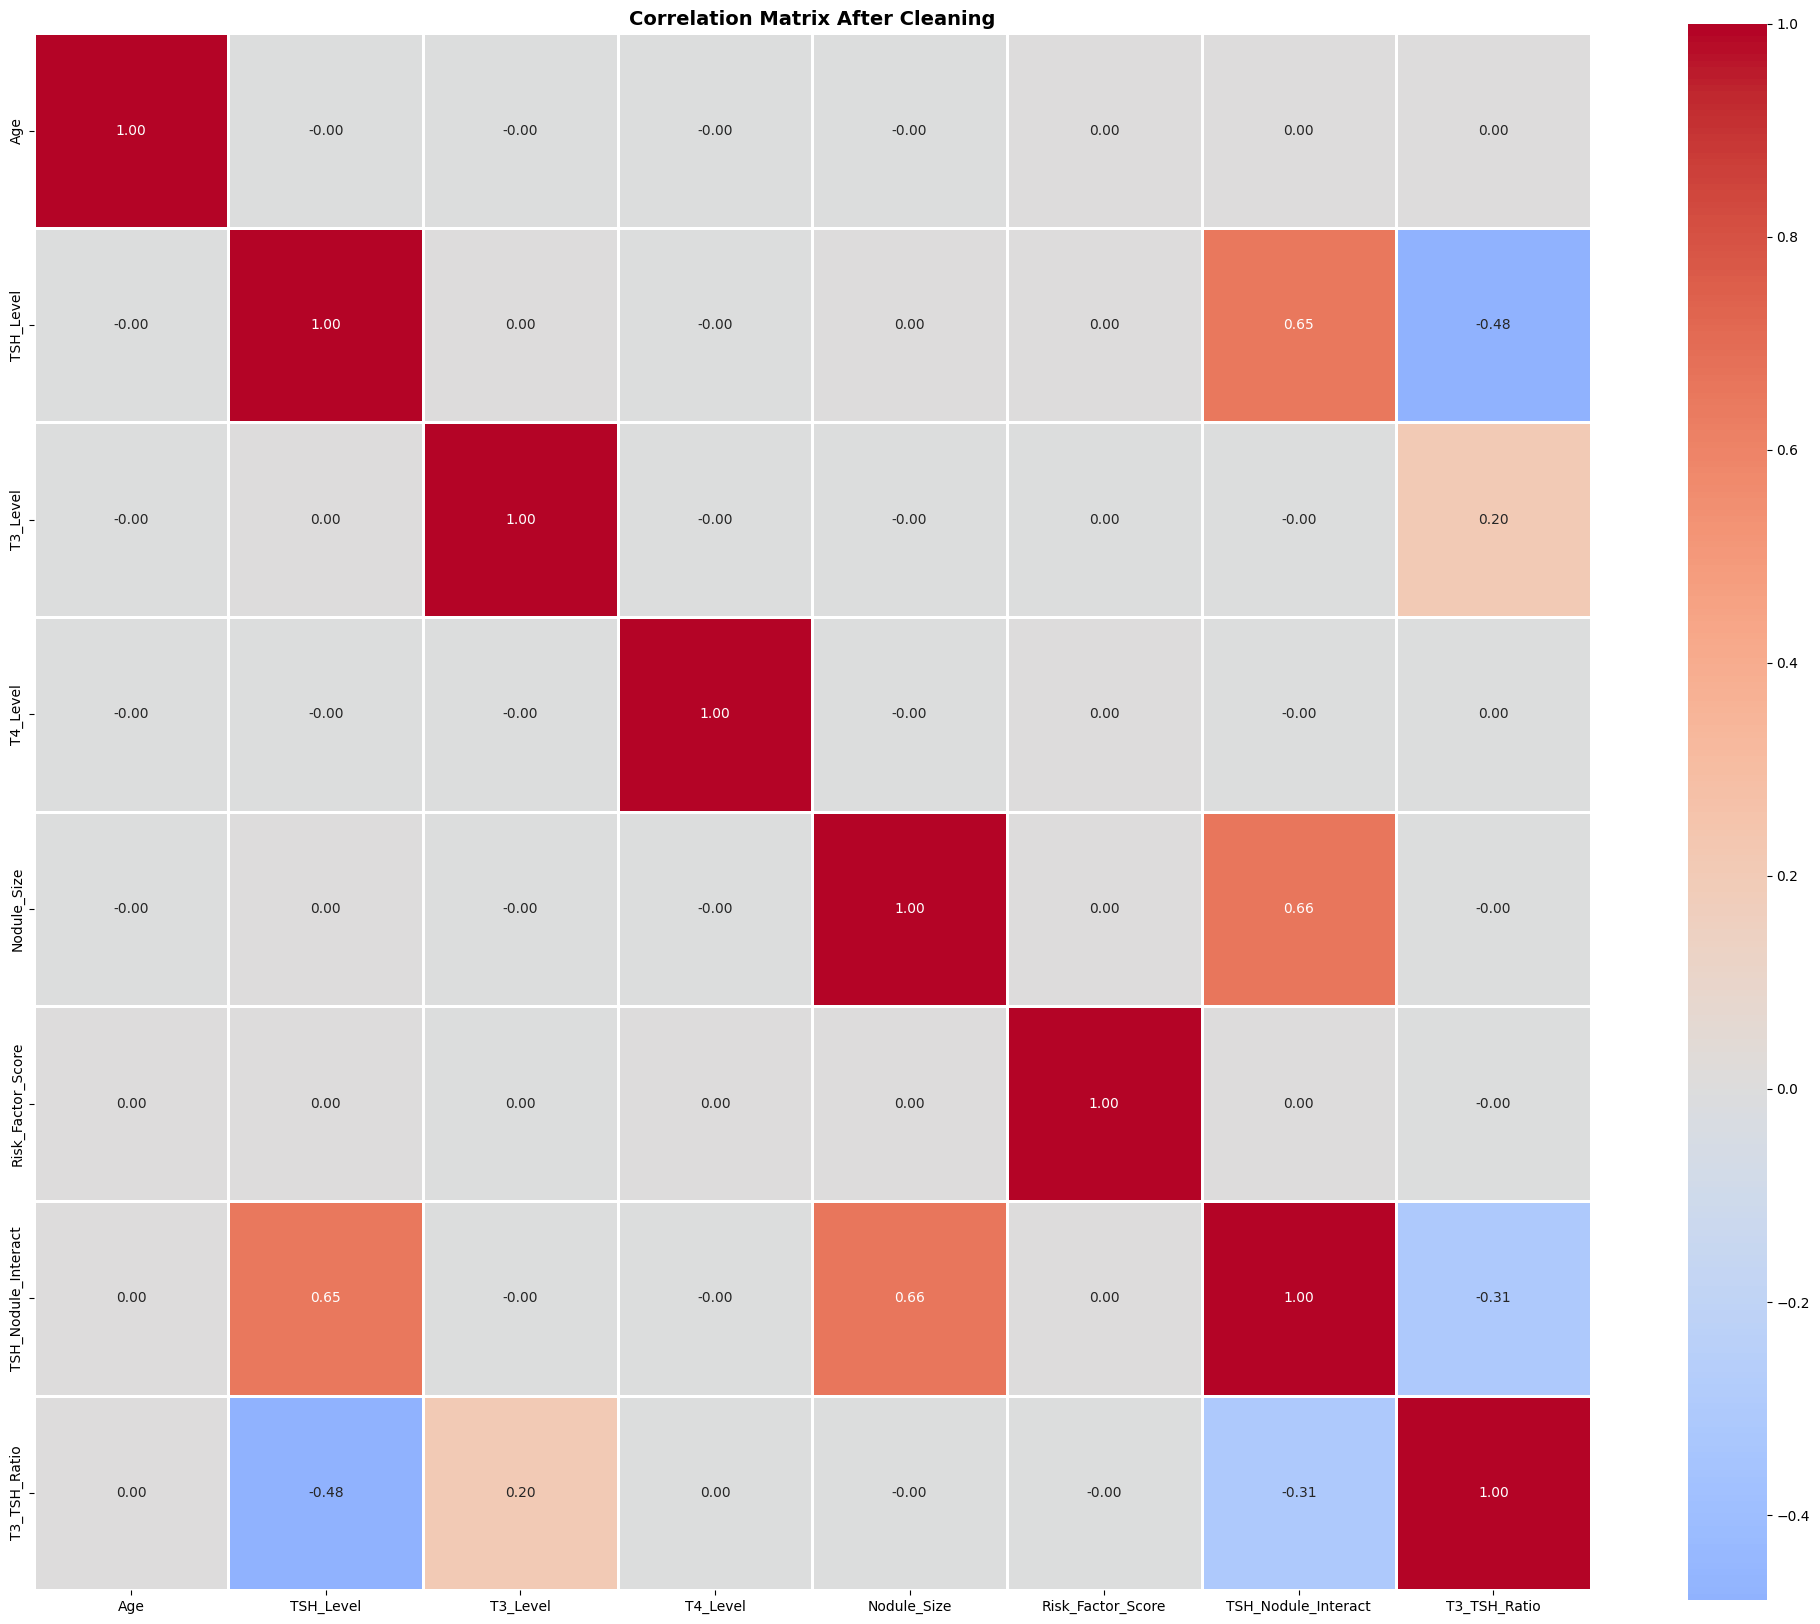

In [8]:
# create correlation matrix 

# generate correlations 

correlation_matrix = df.select_dtypes(include=[np.number]).corr()
print(correlation_matrix.shape)

# take a look at what the correlation matrix looks like 

plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix After Cleaning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../output/correlations_cleaned.png", dpi=300)
plt.show()

# save to correlations csv 
correlation_matrix.to_csv('../output/correlations_cleaned.csv')

In [9]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X = df.drop("Diagnosis", axis=1)  # predictors
y = df["Diagnosis"]               # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Training set head:")
print(X_train.head())
print("Test set shape:", X_test.shape)
print("Test set head:")
print(X_test.head())
print("Training set target shape:", y_train.shape)
print("training set target head:")
print(y_train.head())
print("Test set target shape:", y_test.shape)
print("test set target head:")
print(y_test.head())


Training set shape: (148883, 17)
Training set head:
        Age  Gender Country       Ethnicity Family_History Radiation_Exposure  \
67803    49    Male      UK  Middle Eastern            Yes                 No   
162524   80    Male   India       Caucasian            Yes                 No   
27879    73    Male   India           Asian             No                Yes   
176970   46  Female   China       Caucasian             No                Yes   
12616    29    Male  Brazil         African             No                 No   

       Iodine_Deficiency Smoking Obesity Diabetes  TSH_Level  T3_Level  \
67803                 No      No      No       No       0.59      0.66   
162524                No      No      No       No       8.65      1.27   
27879                Yes      No     Yes       No       0.70      2.42   
176970               Yes     Yes      No       No       7.76      0.78   
12616                Yes      No      No       No       4.14      3.28   

        T4_Level

In [10]:
# save datasets to csv
X_train.to_csv("../data/X_train.csv", index=False)
X_test.to_csv("../data/X_test.csv", index=False)
y_train.to_csv("../data/y_train.csv", index=False)
y_test.to_csv("../data/y_test.csv", index=False)